In [ ]:
# script from Monika:
# /path/to/project
module load HGI/softpack/groups/team152/iibdgc_postprocess/10

MEM=15000
bsub -Is -M"$MEM" -R"select[mem>$MEM] rusage[mem=$MEM]" -G team152 -q cpu-interactive python


import argparse
import scanpy as sc
import plotnine as plt9
import pandas as pd
import numpy as np
import matplotlib as plt
import os
%load_ext autoreload
%autoreload 2
import anndata
import seaborn as sns
import logging
import scipy.stats
import csv
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# fpath="/path/to/project"
# fpath="/path/to/project"

# file provided by Tobi, old annotation
fpath="/path/to/project"
adata=sc.read(fpath) 



In [5]:
out_path="/path/to/git/IIBDGC_GWAS/plots/gene_expression_dot_plots/"

#output path
sc.settings.figdir = "/path/to/git/IIBDGC_GWAS/plots/gene_expression_dot_plots/"

In [7]:
adata_epi=adata[adata.obs['celltype_category'].isin(["Stem cell", "Enterocyte", "Secretory"])]
adata_t=adata[adata.obs['celltype_category']=="T cell"]
adata_b=adata[adata.obs['celltype_category'].isin(["B cell", "Plasma B cell"])]
adata_mye=adata[adata.obs['celltype_category'].isin(["Myeloid"])]
adata_mes=adata[adata.obs['celltype_category'].isin(["Mesenchymal"])]

In [ ]:
np.unique(adata_epi.obs['label'])

In [12]:
out_epi = {'Stem cells OLFM4+': ['SERPINE1', 'PLAU', 'PLAUR'], #,'ASCL2', 'MYC', 'SMOC2'
            'Stem cells OLFM4+ LGR5+': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Stem cells MKI67+': ['SERPINE1', 'PLAU', 'PLAUR'],    
            'Enterocytes progenitor': ['SERPINE1', 'PLAU', 'PLAUR'], #'OLFM4', 'MUC1'
            'Enterocytes crypt/middle': ['SERPINE1', 'PLAU', 'PLAUR'], #, 'FABP1',  'KRT20'
            'Enterocytes top villus': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Enterocytes BEST4+': [ 'SERPINE1', 'PLAU', 'PLAUR'],
            'Endocrine cells': ['SERPINE1', 'PLAU', 'PLAUR'],   
            'Goblet cells': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Goblet cells MKI67+': ['SERPINE1', 'PLAU', 'PLAUR'],      
           'Goblet cells middle/top villus': ['SERPINE1', 'PLAU', 'PLAUR'],        
            'Paneth cells': ['SERPINE1', 'PLAU', 'PLAUR'], #DEFA5, DEFA6, REG3A
            'Tuft cells': ['SERPINE1', 'PLAU', 'PLAUR']
}
out_t = {     
     'T cells CD4+ memory': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells CD4+ CXCR6+': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells CD4+ PASK+': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells CD4+ Treg': ['SERPINE1', 'PLAU', 'PLAUR'], #'BATF', 'ICA1', 'MAF','IL10'
     'T cells CD4+ naive': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells CD4+ proliferating': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells CD4- CD8-': ['SERPINE1', 'PLAU', 'PLAUR'],        
     'T cells CD8+ tissue-resudent': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells CD8+ GZMK+': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells CD8+ FGFBP2+ effector': ['SERPINE1', 'PLAU', 'PLAUR'],
     'T cells gd': ['SERPINE1', 'PLAU', 'PLAUR'], #'CD7', #, 'GZMA', 'TRDC', 'FCER1G'
     'NKs': ['SERPINE1', 'PLAU', 'PLAUR'], 
     'ILCs': ['SERPINE1', 'PLAU', 'PLAUR'] #RORC, IL1R1, IL23R, KIT, TNFSF4, PCDH9
    
}


out_b = { 'B cells': ['SERPINE1', 'PLAU', 'PLAUR'],  
    'B cells activated': ['SERPINE1', 'PLAU', 'PLAUR'],  
          'B cells naive': ['SERPINE1', 'PLAU', 'PLAUR'],
         'B cells memory FCRL2+': ['SERPINE1', 'PLAU', 'PLAUR'],    
          'B cells germinal centre/plasmablasts': ['SERPINE1', 'PLAU', 'PLAUR'],  
         'IgA plasma B cells': ['SERPINE1', 'PLAU', 'PLAUR'],
}

out_mye = {  
            'Monocytes S100A8/9+': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Macrophages CD163+/-': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Macrophages CCL3/4+/- CXCL9/10+/-': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Dendritic cells': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Mast cells': ['SERPINE1', 'PLAU', 'PLAUR']
  
}


out_mes = {
            'Fibroblasts': ['SERPINE1', 'PLAU', 'PLAUR'],
            'Myofibroblasts': ['SERPINE1', 'PLAU', 'PLAUR'],
             'Pericyte cells': ['SERPINE1', 'PLAU', 'PLAUR'], #,'PDGFRB' NOTCH3, MCAM/CD146, RGS5  'HIGD1B', 'STEAP4','FABP4', 
            'Endothelial cells': ['SERPINE1', 'PLAU', 'PLAUR']
           }


In [13]:
def to_df(dictin):
    df=pd.DataFrame.from_dict(dictin, orient='index')
    df=df.apply(lambda x: ', '.join(x[x.notnull()]), axis = 1)
    df=pd.DataFrame(df)
    df=df.rename(columns={0:"gene_markers"})
    df.insert(0,'cell_type',df.index.values)
    return(df)

marker_df=pd.concat([to_df(out_epi), to_df(out_t), to_df(out_b), to_df(out_mye),to_df(out_mes) ])


marker_df.to_csv(out_path+"TableS2_markers.tsv", sep="\t", index=False) 


In [ ]:
cat_order=['Monocytes S100A8/9+', 'Macrophages CD163+', 
           'Macrophages CD163-', 'Macrophages CCL3/4+ CXCL9/10+', 
           'Macrophages CCL3/4- CXCL9/10-', 'Dendritic cells', 'Mast cells']
adata_mye.obs['label']=pd.Categorical(adata_mye.obs['label'], categories=cat_order)
#sc.tl.dendrogram(adata_mye, groupby='label')

sc.settings.file_format_figs="pdf"
sc.pl.dotplot(adata_mye, out_mye, groupby='celltype_label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="myeloid") 
sc.settings.file_format_figs="png"
sc.pl.dotplot(adata_mye, out_mye, groupby='celltype_label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="myeloid") 

In [ ]:
cat_order=[
          'Fibroblasts',
          "Myofibroblasts", 
            'Pericyte cells',
            'Endothelial cells'
          ]
adata_mes.obs['label']=pd.Categorical(adata_mes.obs['label'], categories=cat_order)
#sc.tl.dendrogram(adata_mye, groupby='label')

sc.settings.file_format_figs="pdf"
sc.pl.dotplot(adata_mes, out_mes, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="mesenchymal") 

sc.settings.file_format_figs="png"
sc.pl.dotplot(adata_mes, out_mes, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="mesenchymal") 

In [ ]:
cat_order=['B cells',
           'B cells activated',
           'B cells naive',
           'B cells memory', 
            'B cells memory FCRL2+',        
             'B cells germinal centre/plasmablasts',         
         'IgA plasma B cells JCHAIN+',
        'IgA plasma B cells JCHAIN++',
        'IgA plasma B cells JCHAIN+++']


adata_b.obs['label']=pd.Categorical(adata_b.obs['label'], categories=cat_order)
#sc.tl.dendrogram(adata_mye, groupby='label')

sc.settings.file_format_figs="pdf"
sc.pl.dotplot(adata_b, out_b, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="b_cell")

sc.settings.file_format_figs="png"
sc.pl.dotplot(adata_b, out_b, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="b_cell")

In [ ]:
cat_order= [
     'T cells CD4+ memory',
     'T cells CD4+ CXCR6+',
     'T cells CD4+ PASK+',
     'T cells CD4+ Treg',
     'T cells CD4+ naive',
     'T cells CD4+ proliferating', 
     'T cells CD4- CD8-',  
      'T cells CD8+ tissue-resident',
     'T cells CD8+ GZMK+',
     'T cells CD8+ FGFBP2+ effector',
     'T cells gd',
      'NKs',
      'ILCs',
        ]

adata_t.obs['label']=pd.Categorical(adata_t.obs['label'], categories=cat_order)

#sc.tl.dendrogram(adata_mye, groupby='label')
sc.settings.file_format_figs="pdf"
sc.pl.dotplot(adata_t, out_t, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="t_cell") 

sc.settings.file_format_figs="png"
sc.pl.dotplot(adata_t, out_t, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="t_cell") 

/home/ubuntu/miniconda3/envs/cellpymc/lib/python3.7/site-packages/ipykernel_launcher.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


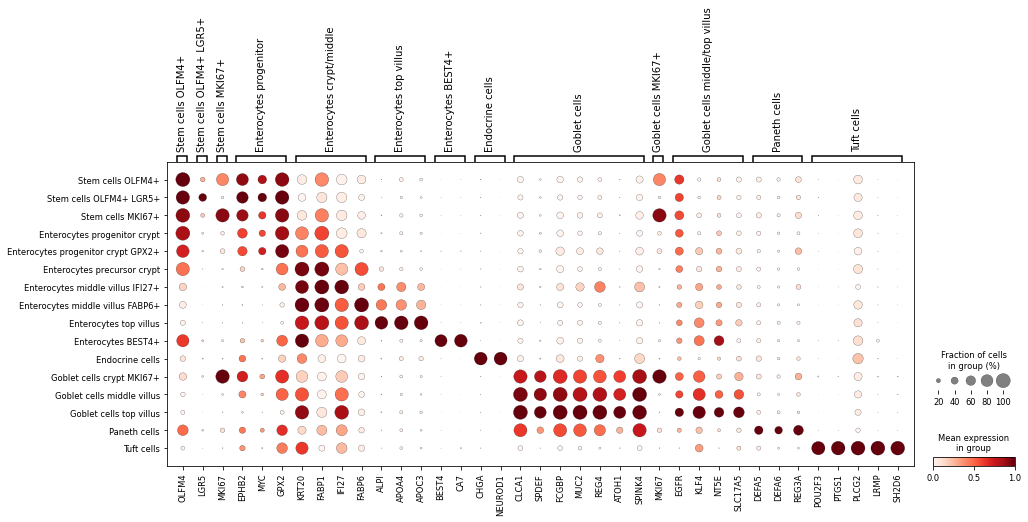

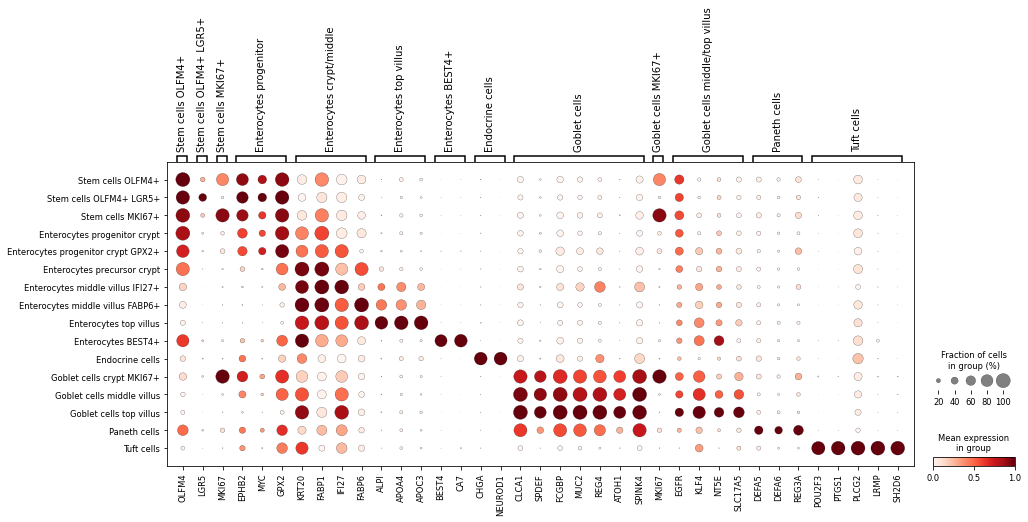

In [19]:
cat_order = [
            'Stem cells OLFM4+',
            'Stem cells OLFM4+ LGR5+',
            'Stem cells MKI67+',          
            'Enterocytes progenitor crypt',
            'Enterocytes progenitor crypt GPX2+',
            'Enterocytes precursor crypt',
            'Enterocytes middle villus IFI27+',
            'Enterocytes middle villus FABP6+',
            'Enterocytes top villus',
            'Enterocytes BEST4+',
            'Endocrine cells',
            'Goblet cells crypt MKI67+',
            'Goblet cells middle villus',
            'Goblet cells top villus',
            'Paneth cells',
            'Tuft cells'
            ]
adata_epi.obs['label']=pd.Categorical(adata_epi.obs['label'], categories=cat_order)


#sc.tl.dendrogram(adata_mye, groupby='label')
sc.settings.file_format_figs="pdf"
sc.pl.dotplot(adata_epi, out_epi, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="epithelial") 

sc.settings.file_format_figs="png"
sc.pl.dotplot(adata_epi, out_epi, groupby='label',
                  gene_symbols='gene_symbols', dendrogram=False,
                  standard_scale='var', show=True, save="epithelial") 